# GraphSAGE — Inductive Representation Learning on Large Graphs
### Paper reproduction (Hamilton, Ying, Leskovec — NeurIPS 2017), PPI dataset

This notebook walks through the paper *"Inductive Representation Learning on
Large Graphs"* (`GraphSAGE.pdf`, arXiv:1706.02216) section by section: each
theoretical part is followed, where relevant, by the real results obtained by
running the paper's original implementation (in `src/graphsage/`, unchanged
from the official `williamleif/GraphSAGE` repo) on the **PPI**
(protein-protein interaction) dataset — the only one of the paper's three
benchmarks that is publicly downloadable (the Citation/Web of Science dataset
is licensed by Thomson Reuters — see Appendix B of the paper).

The actual training does **not** happen in this notebook: it is orchestrated
by the training scripts (`graphsage.supervised_train` /
`graphsage.unsupervised_train`) plus `scripts/baseline_ppi.py` and
`scripts/eval_unsupervised.py`, which produce the files under `logs/` and
`results/` that are only loaded and visualized here.


## 1. Introduction and motivation

Classic node-embedding methods (DeepWalk, node2vec, LINE, ...) learn a free
vector per node, optimized directly (one row of an embedding matrix). This
makes them **transductive**: they only work for nodes seen during training,
and generalize poorly to new nodes or new graphs, because the embedding space
can rotate arbitrarily between two training runs (see Appendix D of the
paper).

**GraphSAGE** (*SAmple and aggreGatE*) instead learns a **function** that
generates a node's embedding by aggregating the features of its local
neighborhood, rather than training one embedding per node. Once trained, this
function can be applied to nodes never seen before (**inductive** setting),
and even to entirely new graphs sharing the same feature distribution (as in
the multi-graph PPI case used in this reproduction).

The paper evaluates GraphSAGE on three node-classification tasks on unseen
nodes:
1. **Citation** (Web of Science) — classifying scientific papers,
2. **Reddit** — classifying posts into communities,
3. **PPI** — classifying protein functions on completely different graphs
   between train and test (cross-graph generalization).


## 2. Related work (summary)

- **Factorization-based approaches** (DeepWalk, node2vec, LINE, GraRep...):
  directly optimize embeddings via random walks + implicit matrix
  factorization. Inherently transductive.
- **Graph Convolutional Networks (Kipf & Welling, 2016)**: propagate and
  aggregate information across the graph with an approximate spectral
  convolution operator, but in their original formulation require the full
  graph Laplacian and operate in a transductive, fixed-graph setting.
- GraphSAGE **generalizes** the GCN idea into an inductive framework with
  arbitrary trainable aggregators (not just a fixed convolution), and
  introduces neighborhood sampling so the per-batch cost is constant,
  independent of graph size.


## 3. Method — Algorithm 1 (forward propagation)

Key idea: at each "hop" $k = 1, \dots, K$, every node aggregates the
representations of its neighbors from the previous hop, concatenates them
with its own representation, and transforms the result with a non-linear
dense layer.

**Algorithm 1 — GraphSAGE embedding generation**

```text
Input : graph G(V,E); initial features {x_v, ∀v∈V}; depth K;
        weight matrices W^k, ∀k∈{1..K}; non-linearity σ;
        aggregator functions AGGREGATE_k, ∀k∈{1..K};
        neighborhood function N: v → 2^V
Output: representations z_v for every v∈V

h_v^0 ← x_v, ∀v∈V
for k = 1..K:
    for v ∈ V:
        h_{N(v)}^k ← AGGREGATE_k( { h_u^{k-1}, ∀u∈N(v) } )
        h_v^k ← σ( W^k · CONCAT(h_v^{k-1}, h_{N(v)}^k) )
    h_v^k ← h_v^k / ||h_v^k||_2 , ∀v∈V
z_v ← h_v^K, ∀v∈V
```

In mathematical form, the node update at every hop is:

$$h_v^k \leftarrow \sigma\Big(\mathbf{W}^k \cdot \text{CONCAT}\big(h_v^{k-1},\, h_{N(v)}^k\big)\Big), \qquad h_v^k \leftarrow \frac{h_v^k}{\lVert h_v^k \rVert_2}$$

Key points:
- $N(v)$ is **not** the full neighborhood, but a fixed-size sample $S$
  re-drawn at every iteration — this makes the per-batch cost
  $O\!\left(\prod_{i=1}^{K} S_i\right)$, independent of $|V|$.
- In the paper: $K=2$ with $S_1=25$, $S_2=10$ (the same default values used
  in this reproduction, see Section 7 below).
- Connection to the **Weisfeiler-Lehman** isomorphism test: if $K=|V|$, the
  weights are the identity, and the aggregator is an exact hash function,
  Algorithm 1 becomes exactly the WL test ("naive vertex refinement").
  GraphSAGE is a continuous, trainable approximation of this test.


### 3.1 Visualizing neighborhood sampling

The figure below illustrates the sampling step at the heart of Algorithm 1:
starting from a target node $v$ (blue), a fixed-size sample of its direct
neighbors is drawn (green, size $S_1$), and then a fixed-size sample of
*their* neighbors is drawn in turn (yellow, size $S_2$) — every other node in
the graph (gray) is never touched for this particular minibatch. This is
what keeps the per-batch cost fixed at $O(S_1 \cdot S_2)$ regardless of how
large or densely connected the full graph is.

For legibility this uses a small synthetic graph with illustrative sample
sizes $S_1=3$, $S_2=2$ (the actual PPI experiments below use the paper's
default $S_1=25$, $S_2=10$ on graphs with ~2,373 nodes each).


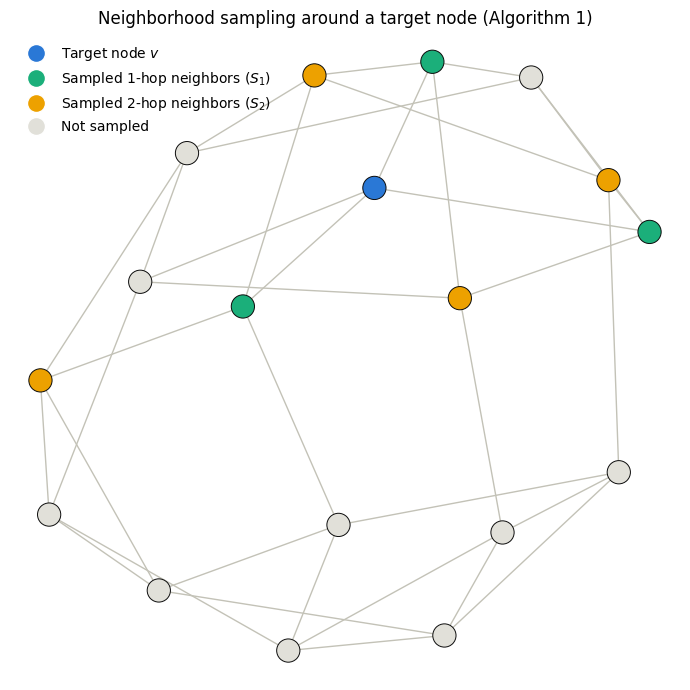

In [1]:
import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

rng = np.random.RandomState(7)

# a small synthetic 4-regular graph, purely for illustration (this is NOT PPI data)
demo_graph = nx.random_regular_graph(d=4, n=18, seed=7)
target_node = 0
S1, S2 = 3, 2

one_hop_all = list(demo_graph.neighbors(target_node))
one_hop_sampled = list(rng.choice(one_hop_all, size=min(S1, len(one_hop_all)), replace=False))

two_hop_sampled = set()
for u in one_hop_sampled:
    candidates = [n for n in demo_graph.neighbors(u) if n != target_node and n not in one_hop_sampled]
    if candidates:
        picked = rng.choice(candidates, size=min(S2, len(candidates)), replace=False)
        two_hop_sampled.update(picked)

color_target, color_1hop, color_2hop, color_unsampled = "#2a78d6", "#1baf7a", "#eda100", "#e1e0d9"
node_colors = []
for n in demo_graph.nodes():
    if n == target_node:
        node_colors.append(color_target)
    elif n in one_hop_sampled:
        node_colors.append(color_1hop)
    elif n in two_hop_sampled:
        node_colors.append(color_2hop)
    else:
        node_colors.append(color_unsampled)

np.random.seed(7)  # networkx 1.11's spring_layout has no `seed` kwarg; seed the global RNG instead
pos = nx.spring_layout(demo_graph)

# Draw with plain matplotlib (rather than nx.draw_*) to avoid a networkx
# 1.11 / matplotlib incompatibility in networkx's own drawing helpers, and
# for full control over the mark style.
fig, ax = plt.subplots(figsize=(7, 7))
for u, v in demo_graph.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    ax.plot([x0, x1], [y0, y1], color="#c3c2b7", linewidth=1, zorder=1)
xs = [pos[n][0] for n in demo_graph.nodes()]
ys = [pos[n][1] for n in demo_graph.nodes()]
ax.scatter(xs, ys, s=280, c=node_colors, edgecolors="#0b0b0b", linewidths=0.7, zorder=2)
ax.set_title("Neighborhood sampling around a target node (Algorithm 1)")
ax.axis("off")
ax.legend(handles=[
    Line2D([0], [0], marker="o", color="w", markerfacecolor=color_target, markersize=13, label="Target node $v$"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=color_1hop, markersize=13, label="Sampled 1-hop neighbors ($S_1$)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=color_2hop, markersize=13, label="Sampled 2-hop neighbors ($S_2$)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=color_unsampled, markersize=13, label="Not sampled"),
], loc="upper left", frameon=False)
fig.tight_layout()

results_dir = os.path.join(os.getcwd(), "results")
os.makedirs(results_dir, exist_ok=True)
fig.savefig(os.path.join(results_dir, "sampling_illustration.png"), dpi=140)
plt.show()


## 4. Algorithm 2 — minibatch forward propagation

For SGD training, the paper first samples the set of nodes that will be
needed (working backwards, from $\mathcal{B}^K$ = the target minibatch down
to $\mathcal{B}^0$ = the leaf nodes with only raw features), then runs the
aggregation forward:

```text
B^K ← B                                    # target nodes of the minibatch
for k = K..1:
    B^{k-1} ← B^k
    for u ∈ B^k:
        B^{k-1} ← B^{k-1} ∪ N_k(u)          # add sampled neighbors

h_u^0 ← x_v, ∀v ∈ B^0
for k = 1..K:
    for u ∈ B^k:
        h_{N(u)}^k ← AGGREGATE_k({h_{u'}^{k-1}, ∀u' ∈ N_k(u)})
        h_u^k ← σ(W^k · CONCAT(h_u^{k-1}, h_{N(u)}^k))
        h_u^k ← h_u^k / ||h_u^k||_2
z_u ← h_u^K, ∀u ∈ B
```

Counter-intuitive note: with $K=2$, $S_1=25$, $S_2=10$, this backward
sampling means that $S_2=10$ direct neighbors and $S_1 \cdot S_2 = 250$
2-hop neighbors are sampled per target node — the indices $1,2$ refer to the
iteration order of Algorithm 1, not the distance from the target node.


## 5. Objective function

**Unsupervised** (Eq. 1 of the paper) — encourages nodes that co-occur on a
random walk to have similar representations, and "distant" nodes (sampled as
negatives) to have distinct representations:

$$J_{\mathcal G}(z_u) = -\log\big(\sigma(z_u^\top z_v)\big) - Q \cdot \mathbb{E}_{v_n \sim P_n(v)}\log\big(\sigma(-z_u^\top z_{v_n})\big)$$

where $v$ co-occurs with $u$ on a fixed-length random walk, $\sigma$ is the
sigmoid, $P_n$ is the negative-sampling distribution (here: unigram over node
degrees with smoothing $0.75$, $Q=20$ negative samples — Appendix C), and
$z_u, z_v$ are generated by Algorithm 1/2, **not** looked up from a table.

**Supervised**: the unsupervised loss is replaced (or complemented) by a
cross-entropy on the downstream task. For PPI, which is **multi-label**
(every protein can have several GO functions at once, out of 121 possible),
a per-class sigmoid cross-entropy is used instead of multi-class softmax
(`--sigmoid true` flag in `supervised_train.py`).


## 6. Aggregator architectures

The paper compares four aggregators (all used in this reproduction, Section
7):

**Mean aggregator / GraphSAGE-GCN.** Elementwise average of the neighbors.
The "convolutional" variant (used for `GraphSAGE-GCN`) does *not* concatenate
the node's own representation with the neighborhood one (no skip
connection):

$$h_v^k \leftarrow \sigma\Big(\mathbf{W}\cdot \text{MEAN}\big(\{h_v^{k-1}\}\cup\{h_u^{k-1}, \forall u\in N(v)\}\big)\Big)$$

This is a linear approximation of Kipf & Welling's localized spectral
convolution, adapted to the inductive setting.

**LSTM aggregator.** Applies an LSTM to the neighbors in random order (a
fresh random permutation per batch) — not permutation-invariant in principle,
but empirically works very well (Section 4.4 of the paper).

**Pooling aggregator** (`GraphSAGE-pool`, max-pooling). Each neighbor is
passed through a shared MLP, then an elementwise max is applied:

$$\text{AGGREGATE}_k^{pool} = \max\Big(\big\{\sigma(\mathbf{W}_{pool}\, h_{u_i}^k + b),\ \forall u_i \in N(v)\big\}\Big)$$

The paper notes no significant difference between max- and mean-pooling, and
uses max-pooling as the official "pool" aggregator in Table 1.


### 6.1 Visualizing the four aggregators

Same self/neighbor inputs, four different ways of turning them into the next
layer's representation. Colors here match the ones used consistently for
these four variants throughout the rest of this notebook (results tables,
loss curves, etc.).


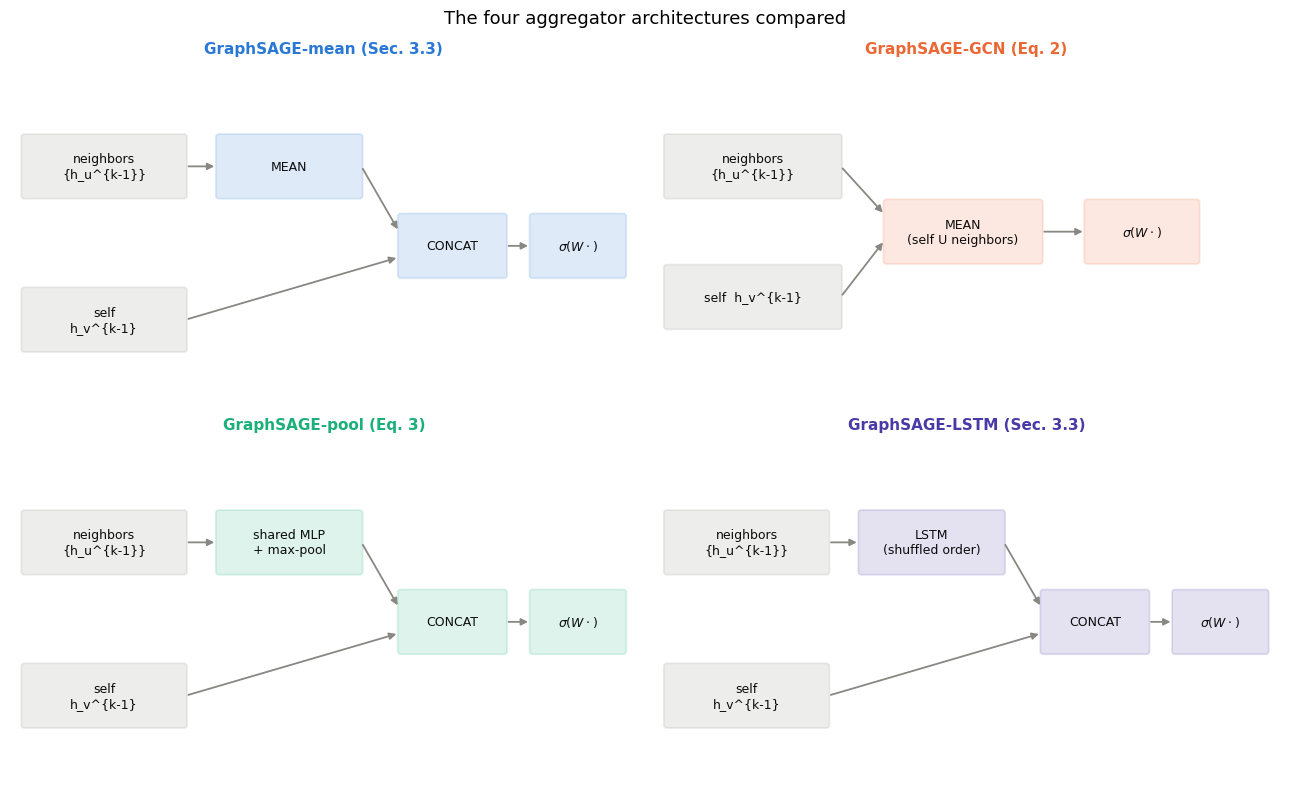

In [2]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

MODEL_COLORS = {
    "GraphSAGE-GCN": "#eb6834",
    "GraphSAGE-mean": "#2a78d6",
    "GraphSAGE-LSTM": "#4a3aa7",
    "GraphSAGE-pool": "#1baf7a",
}

def _box(ax, xy, w, h, text, color):
    x, y = xy
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.05",
                                 linewidth=1.3, edgecolor=color, facecolor=color, alpha=0.15))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=9, color="#0b0b0b")

def _arrow(ax, p0, p1, color="#898781"):
    ax.annotate("", xy=p1, xytext=p0,
                arrowprops=dict(arrowstyle="-|>", color=color, lw=1.3, shrinkA=2, shrinkB=2))

def draw_two_branch(ax, title, color, neigh_label, combine_label):
    '''mean / pool / LSTM: neighbors and self are transformed on separate
    branches, then combined via CONCAT (the Algorithm 1 skip connection).'''
    ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis("off")
    ax.set_title(title, fontsize=11, color=color, fontweight="bold")
    _box(ax, (0.2, 3.6), 2.6, 1.1, "neighbors\n{h_u^{k-1}}", "#898781")
    _box(ax, (0.2, 0.9), 2.6, 1.1, "self\nh_v^{k-1}", "#898781")
    _box(ax, (3.3, 3.6), 2.3, 1.1, neigh_label, color)
    _arrow(ax, (2.8, 4.15), (3.3, 4.15))
    _box(ax, (6.2, 2.2), 1.7, 1.1, combine_label, color)
    _arrow(ax, (5.6, 4.15), (6.2, 3.0))
    _arrow(ax, (2.8, 1.45), (6.2, 2.55))
    _box(ax, (8.3, 2.2), 1.5, 1.1, "$\\sigma(W \\cdot)$", color)
    _arrow(ax, (7.9, 2.75), (8.3, 2.75))

def draw_gcn(ax, title, color):
    '''GCN: self and neighbors are averaged *together* before a single
    shared transform -- no separate branches, no skip connection.'''
    ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis("off")
    ax.set_title(title, fontsize=11, color=color, fontweight="bold")
    _box(ax, (0.2, 3.6), 2.8, 1.1, "neighbors\n{h_u^{k-1}}", "#898781")
    _box(ax, (0.2, 1.3), 2.8, 1.1, "self  h_v^{k-1}", "#898781")
    _box(ax, (3.7, 2.45), 2.5, 1.1, "MEAN\n(self U neighbors)", color)
    _arrow(ax, (3.0, 4.15), (3.7, 3.3))
    _arrow(ax, (3.0, 1.85), (3.7, 2.85))
    _box(ax, (6.9, 2.45), 1.8, 1.1, "$\\sigma(W \\cdot)$", color)
    _arrow(ax, (6.2, 3.0), (6.9, 3.0))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
draw_two_branch(axes[0, 0], "GraphSAGE-mean (Sec. 3.3)", MODEL_COLORS["GraphSAGE-mean"],
                "MEAN", "CONCAT")
draw_gcn(axes[0, 1], "GraphSAGE-GCN (Eq. 2)", MODEL_COLORS["GraphSAGE-GCN"])
draw_two_branch(axes[1, 0], "GraphSAGE-pool (Eq. 3)", MODEL_COLORS["GraphSAGE-pool"],
                "shared MLP\n+ max-pool", "CONCAT")
draw_two_branch(axes[1, 1], "GraphSAGE-LSTM (Sec. 3.3)", MODEL_COLORS["GraphSAGE-LSTM"],
                "LSTM\n(shuffled order)", "CONCAT")
fig.suptitle("The four aggregator architectures compared", fontsize=13)
fig.tight_layout()

results_dir = os.path.join(os.getcwd(), "results")
os.makedirs(results_dir, exist_ok=True)
fig.savefig(os.path.join(results_dir, "aggregator_architectures.png"), dpi=140)
plt.show()


## 7. Experimental setup of this reproduction

- **Dataset**: **PPI only** (public at http://snap.stanford.edu/graphsage/,
  cited in the paper itself). 24 graphs (20 train / 2 val / 2 test), features
  = positional/motif gene sets + immunological signatures, labels = 121 gene
  ontology terms (multi-label).
- **Baselines**: Random (Bernoulli draws at the train positive rate) and Raw
  features (`OneVsRestClassifier(SGDClassifier(loss="log"))`, as described in
  Appendix C) — implemented in `scripts/baseline_ppi.py`.
- **GraphSAGE**: 4 aggregators (`graphsage_mean`, `gcn`, `graphsage_seq` i.e.
  LSTM, `graphsage_maxpool` i.e. pool) × {supervised, unsupervised} = 8 runs,
  **a single run per variant** (not the full sweep from Appendix C), with
  hyperparameters left at the code's defaults — which the code comments
  themselves mark as "left to default values in main experiments": $K=2$,
  $S_1=25$, $S_2=10$, hidden dimension 128 (×2 if concatenated), batch size
  512, 10 epochs for supervised / 1 epoch for unsupervised, 20 negative
  samples.
- For the unsupervised variants, the resulting embeddings are then evaluated
  by training a logistic regression classifier **only on the training
  nodes** and evaluating on the test nodes (`scripts/eval_unsupervised.py`),
  exactly as described in Appendix C.


## 8. Results

The cells below load the results produced by the individual training/eval
runs (baselines in `results/baseline_ppi.json`, supervised F1 in
`logs/sup-ppi/<model>_small_0.0100/test_stats.txt`, unsupervised F1 in
`results/eval_unsup_<model>.json`) and compare them against the PPI columns
of Table 1 in the paper.


In [3]:
import json, os, re
import pandas as pd

REPO = os.path.abspath(os.path.join(os.getcwd()))
LOGS = os.path.join(REPO, "logs")
RESULTS = os.path.join(REPO, "results")

MODELS = [
    ("graphsage_mean", "GraphSAGE-mean"),
    ("gcn", "GraphSAGE-GCN"),
    ("graphsage_seq", "GraphSAGE-LSTM"),
    ("graphsage_maxpool", "GraphSAGE-pool"),
]

PAPER = {
    "Random": (0.396, 0.396),
    "Raw features": (0.422, 0.422),
    "GraphSAGE-GCN": (0.465, 0.500),
    "GraphSAGE-mean": (0.486, 0.598),
    "GraphSAGE-LSTM": (0.482, 0.612),
    "GraphSAGE-pool": (0.502, 0.600),
}

def parse_test_stats(path):
    with open(path) as fp:
        content = fp.read()
    m = re.search(r"f1_micro=([\d.]+)", content)
    return float(m.group(1)) if m else None

with open(os.path.join(RESULTS, "baseline_ppi.json")) as fp:
    baseline = json.load(fp)

rows = []
rows.append(["Random", baseline["random"]["f1_micro"], baseline["random"]["f1_micro"],
             *PAPER["Random"]])
rows.append(["Raw features", baseline["raw_features"]["f1_micro"], baseline["raw_features"]["f1_micro"],
             *PAPER["Raw features"]])

for model_flag, display_name in MODELS:
    with open(os.path.join(RESULTS, f"eval_unsup_{model_flag}.json")) as fp:
        unsup_f1 = json.load(fp)["f1_micro"]
    sup_f1 = parse_test_stats(os.path.join(LOGS, "sup-ppi", f"{model_flag}_small_0.0100", "test_stats.txt"))
    rows.append([display_name, unsup_f1, sup_f1, *PAPER[display_name]])

df = pd.DataFrame(rows, columns=["Name", "Unsup. F1 (reproduced)", "Sup. F1 (reproduced)",
                                   "Unsup. F1 (paper)", "Sup. F1 (paper)"])
df = df.round(3)
df


,Name,Unsup. F1 (reproduced),Sup. F1 (reproduced),Unsup. F1 (paper),Sup. F1 (paper)
0,Random,0.398,0.398,0.396,0.396
1,Raw features,0.434,0.434,0.422,0.422
2,GraphSAGE-mean,0.464,0.585,0.486,0.598
3,GraphSAGE-GCN,0.454,0.521,0.465,0.500
4,GraphSAGE-LSTM,0.446,0.607,0.482,0.612
5,GraphSAGE-pool,0.482,0.602,0.502,0.600


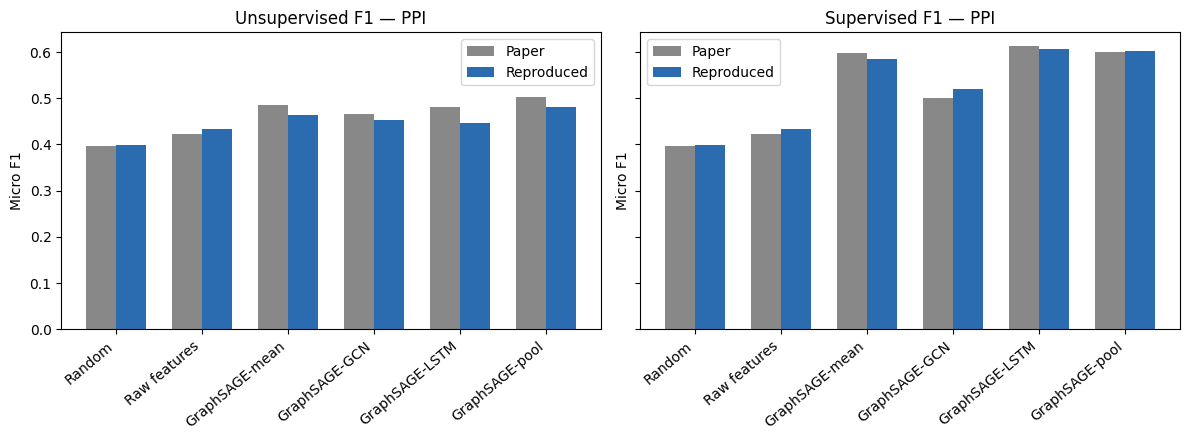

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
x = np.arange(len(df))
width = 0.35

for ax, col_repro, col_paper, title in [
    (axes[0], "Unsup. F1 (reproduced)", "Unsup. F1 (paper)", "Unsupervised F1 — PPI"),
    (axes[1], "Sup. F1 (reproduced)", "Sup. F1 (paper)", "Supervised F1 — PPI"),
]:
    ax.bar(x - width/2, df[col_paper], width, label="Paper", color="#888888")
    ax.bar(x + width/2, df[col_repro], width, label="Reproduced", color="#2b6cb0")
    ax.set_xticks(x)
    ax.set_xticklabels(df["Name"], rotation=40, ha="right")
    ax.set_title(title)
    ax.set_ylabel("Micro F1")
    ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "ppi_comparison.png"), dpi=140)
plt.show()


### Training time per variant

Conceptual analogue of Figure 2A in the paper (which compares
training/inference time across variants on Reddit): here we measure the
actual training time per aggregator on the PPI dataset, extracted from the
run logs.


In [5]:
import re

def extract_last_avg_time(log_path):
    '''Extract the last `time=` value (average seconds per iteration)
    printed by the training script in its log.'''
    if not os.path.exists(log_path):
        return None
    last = None
    with open(log_path, encoding="utf-8", errors="ignore") as fp:
        for line in fp:
            m = re.search(r"time=\s*([\d.]+)\s*$", line.strip())
            if m:
                last = float(m.group(1))
    return last

timing_rows = []
for model_flag, display_name in MODELS:
    sup_time = extract_last_avg_time(os.path.join(LOGS, f"sup_{model_flag}.log"))
    unsup_time = extract_last_avg_time(os.path.join(LOGS, f"unsup_{model_flag}.log"))
    timing_rows.append([display_name, sup_time, unsup_time])

timing_df = pd.DataFrame(timing_rows, columns=["Name", "Sup. sec/iter", "Unsup. sec/iter"])
timing_df


,Name,Sup. sec/iter,Unsup. sec/iter
0,GraphSAGE-mean,0.39152,0.01130
1,GraphSAGE-GCN,0.37599,0.01129
2,GraphSAGE-LSTM,0.79889,0.15614
3,GraphSAGE-pool,0.42255,0.05469


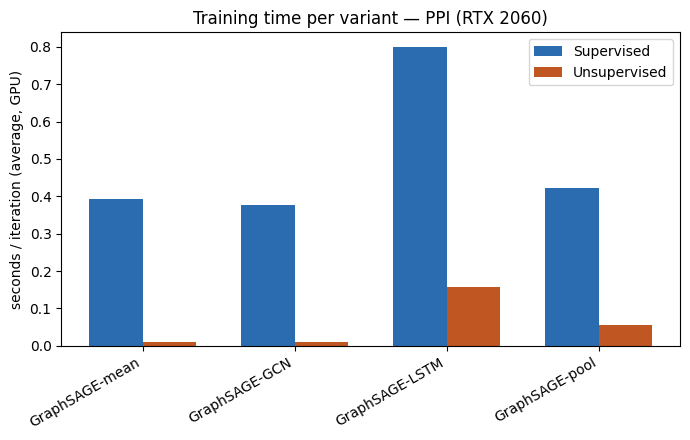

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(timing_df))
width = 0.35
ax.bar(x - width/2, timing_df["Sup. sec/iter"], width, label="Supervised", color="#2b6cb0")
ax.bar(x + width/2, timing_df["Unsup. sec/iter"], width, label="Unsupervised", color="#c05621")
ax.set_xticks(x)
ax.set_xticklabels(timing_df["Name"], rotation=30, ha="right")
ax.set_ylabel("seconds / iteration (average, GPU)")
ax.set_title("Training time per variant — PPI (RTX 2060)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "ppi_timing.png"), dpi=140)
plt.show()


### 8.1 Training dynamics: loss between validation checkpoints

Every training script prints the training loss at every step (`--print_every
5`) but only *re-evaluates* on a validation sample every `--validate_iter`
steps (5000 by default) -- since one PPI epoch is much shorter than that, in
practice validation only refreshes once per epoch, while the training loss
is visible at a much finer grain in between. Plotting both against the same
step axis makes that visible directly: a noisy, high-frequency training
curve against a coarse, "staircase" validation curve -- i.e. literally what
the optimizer's gradient steps are doing *between* the evaluations that
report it.


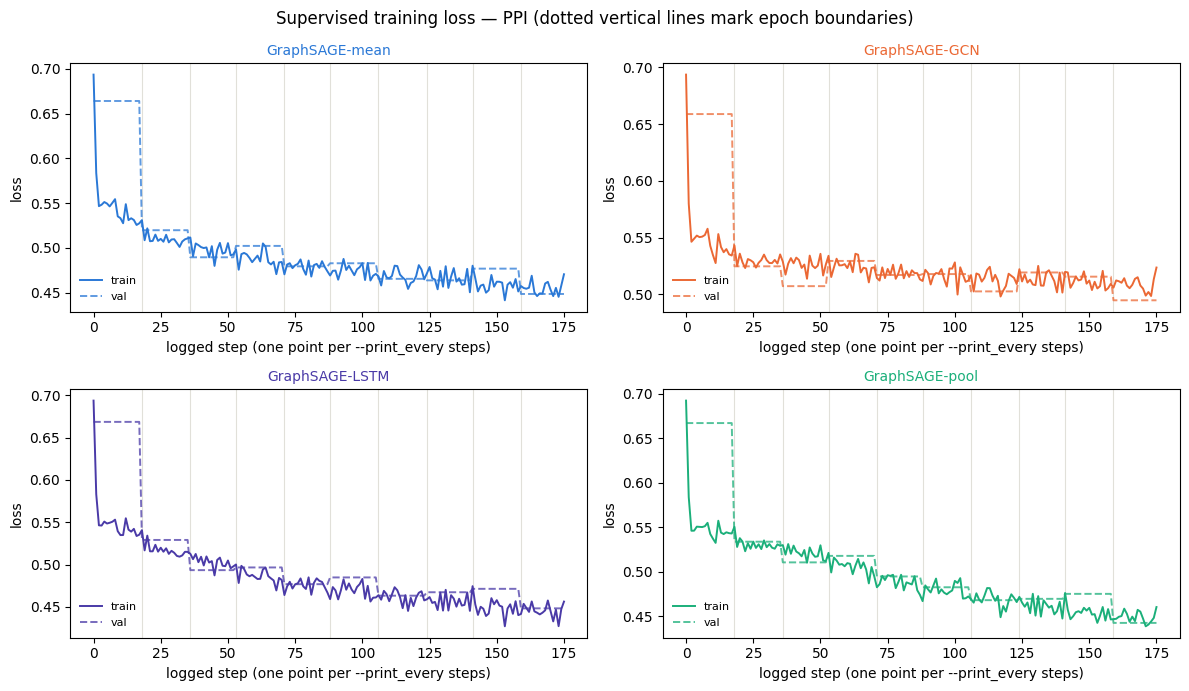

In [7]:
import re

MODEL_COLORS = {
    "GraphSAGE-GCN": "#eb6834",
    "GraphSAGE-mean": "#2a78d6",
    "GraphSAGE-LSTM": "#4a3aa7",
    "GraphSAGE-pool": "#1baf7a",
}

def parse_training_log(log_path):
    '''Read a supervised_train.py / unsupervised_train.py console log and
    return, in print order, the training step index, train_loss, val_loss,
    and the step indices where a new epoch started.'''
    steps, train_loss, val_loss, epoch_steps = [], [], [], []
    if not os.path.exists(log_path):
        return steps, train_loss, val_loss, epoch_steps
    step = 0
    with open(log_path, encoding="utf-8", errors="ignore") as fp:
        for line in fp:
            if line.startswith("Epoch:"):
                epoch_steps.append(step)
                continue
            m = re.search(r"train_loss=\s*([\d.]+).*?val_loss=\s*([\d.]+)", line)
            if m:
                train_loss.append(float(m.group(1)))
                val_loss.append(float(m.group(2)))
                steps.append(step)
                step += 1
    return steps, train_loss, val_loss, epoch_steps

def plot_loss_curves(log_prefix, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    for ax, (model_flag, display_name) in zip(axes.flat, MODELS):
        steps, tr, va, epochs = parse_training_log(os.path.join(LOGS, f"{log_prefix}_{model_flag}.log"))
        color = MODEL_COLORS[display_name]
        for e in epochs[1:]:
            ax.axvline(e, color="#e1e0d9", lw=0.8, zorder=0)
        ax.plot(steps, tr, color=color, lw=1.4, label="train")
        ax.plot(steps, va, color=color, lw=1.4, ls="--", alpha=0.75, label="val")
        ax.set_title(display_name, color=color, fontsize=10)
        ax.set_xlabel("logged step (one point per --print_every steps)")
        ax.set_ylabel("loss")
        ax.legend(frameon=False, fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    return fig

fig_sup = plot_loss_curves("sup", "Supervised training loss — PPI (dotted vertical lines mark epoch boundaries)")
fig_sup.savefig(os.path.join(RESULTS, "ppi_supervised_loss_curves.png"), dpi=140)
plt.show()


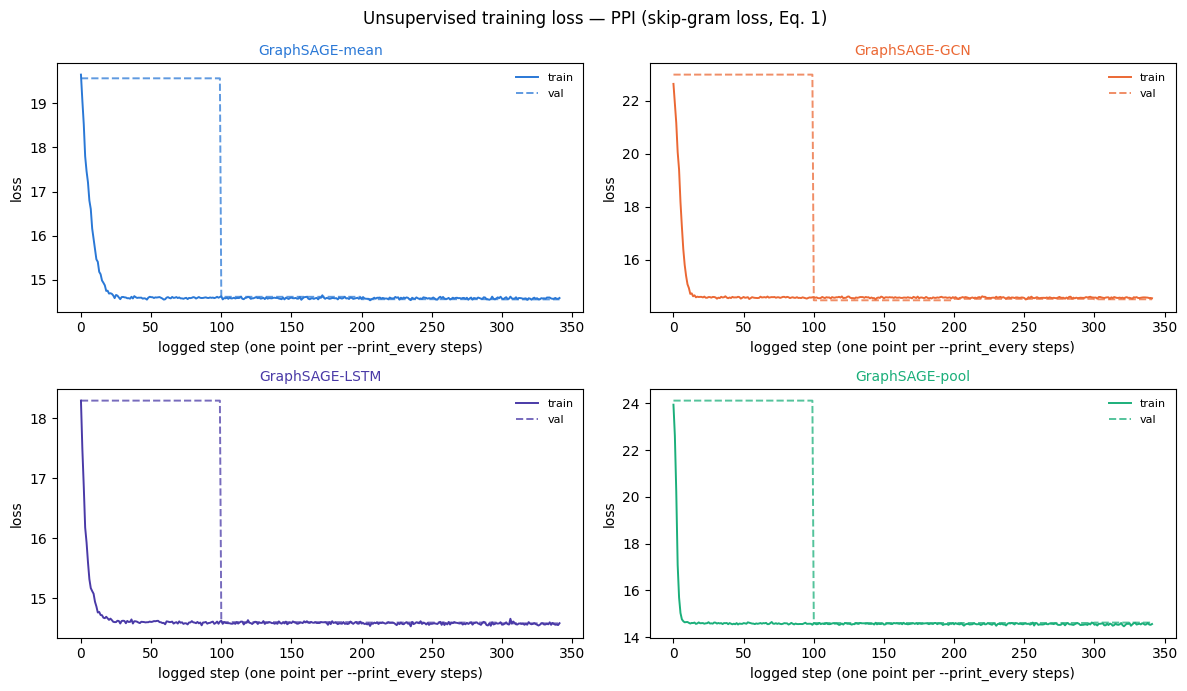

In [8]:
fig_unsup = plot_loss_curves("unsup", "Unsupervised training loss — PPI (skip-gram loss, Eq. 1)")
fig_unsup.savefig(os.path.join(RESULTS, "ppi_unsupervised_loss_curves.png"), dpi=140)
plt.show()


### 8.2 Watching the embedding space train: phases of aggregation

Rather than looking only at the final, fully-trained embeddings, this
section tracks how they get there. `scripts/train_embedding_snapshots.py`
re-runs the best-performing unsupervised aggregator (`GraphSAGE-pool`) as a
**single continuous training run** -- same seeds, same minibatch order as
the reproduction above -- and dumps embeddings for every node at 7 points
along the way: right after initialization (step 0), and after 50, 200, 800,
3,000, 8,000 and 17,050 (~1 full epoch) gradient steps. Because it's one
uninterrupted run, these are genuine snapshots of a single trajectory, not
independent restarts.

To make the stages visually comparable, a **fixed subsample of ~1,000 nodes**
(stratified by split) is tracked through every stage, and each projection
method below is fit **once** -- on the fully-trained (step 17,050) stage for
PCA, jointly across all 7 stages at once for t-SNE -- so that a point's
position means the same thing in every panel, and its movement across panels
is directly readable rather than an artifact of re-fitting the projection
each time.


In [9]:
import sys
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

sys.path.insert(0, os.path.join(REPO, "src"))
from graphsage.utils import load_data

EMBED_MODEL = "graphsage_maxpool"  # our strongest unsupervised variant (see table above)
SNAPSHOT_STEPS = [0, 50, 200, 800, 3000, 8000, 17050]
snapshot_root = os.path.join(LOGS, "unsup-ppi", f"{EMBED_MODEL}_small_0.000010", "snapshots")

split_colors = {"train": "#2a78d6", "val": "#eda100", "test": "#e34948"}
blue_seq_cmap = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95", "#0d366b"])


def load_snapshot(step):
    d = os.path.join(snapshot_root, "step_%05d" % step)
    emb = np.load(os.path.join(d, "val.npy"))
    with open(os.path.join(d, "val.txt")) as fp:
        ids = [int(line.strip()) for line in fp if line.strip()]
    return emb, {node_id: row for row, node_id in enumerate(ids)}


G, _, _, _, _ = load_data("data/ppi/ppi", load_walks=False)

# node ids present in every snapshot (all of them, in practice -- every
# snapshot covers all 56,944 nodes -- but this keeps things robust)
_, final_id_to_row = load_snapshot(SNAPSHOT_STEPS[-1])
node_list = [n for n in G.nodes() if n in final_id_to_row]
node_split = np.array(["test" if G.node[n]["test"] else ("val" if G.node[n]["val"] else "train") for n in node_list])
node_degree = np.array([G.degree(n) for n in node_list])

# one fixed, stratified-by-split subsample, shared by every stage and both
# projection methods below (so "the same nodes" are being tracked throughout)
n_sub = 1000
rng_sub = np.random.RandomState(123)
sub_mask = np.zeros(len(node_list), dtype=bool)
for split_name in split_colors:
    idx = np.where(node_split == split_name)[0]
    take = max(1, int(round(n_sub * len(idx) / len(node_list))))
    sub_mask[rng_sub.choice(idx, size=min(take, len(idx)), replace=False)] = True

sub_ids = [node_list[i] for i in range(len(node_list)) if sub_mask[i]]
sub_split = node_split[sub_mask]
sub_degree = node_degree[sub_mask]

snapshot_embeddings = {}
for step in SNAPSHOT_STEPS:
    emb, id_to_row = load_snapshot(step)
    snapshot_embeddings[step] = emb[[id_to_row[nid] for nid in sub_ids]]

print(f"Tracking {len(sub_ids)} nodes ({(sub_split=='train').sum()} train / "
      f"{(sub_split=='val').sum()} val / {(sub_split=='test').sum()} test) "
      f"across {len(SNAPSHOT_STEPS)} training snapshots")


Removed 0 nodes that lacked proper annotations due to networkx versioning issues
Loaded data.. now preprocessing..
Tracking 1000 nodes (789 train / 114 val / 97 test) across 7 training snapshots


In [10]:
def plot_stage_small_multiples(coords_by_step, title, xlabel, ylabel, suptitle_color="#0b0b0b"):
    fig, axes = plt.subplots(1, len(SNAPSHOT_STEPS), figsize=(3.1 * len(SNAPSHOT_STEPS), 3.6), sharex=True, sharey=True)
    for ax, step in zip(axes, SNAPSHOT_STEPS):
        coords = coords_by_step[step]
        for split_name, color in split_colors.items():
            mask = sub_split == split_name
            ax.scatter(coords[mask, 0], coords[mask, 1], s=9, alpha=0.45, color=color, linewidths=0)
        ax.set_title(f"step {step}", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
    axes[0].set_ylabel(ylabel)
    fig.text(0.5, -0.02, xlabel, ha="center", fontsize=10)
    handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=9, label=s)
               for s, c in split_colors.items()]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False)
    fig.suptitle(title, y=1.2, color=suptitle_color)
    fig.tight_layout()
    return fig


def plot_stage_trajectories(coords_by_step, title, xlabel, ylabel, n_traj=35):
    rng_traj = np.random.RandomState(7)
    traj_idx = rng_traj.choice(len(sub_ids), size=min(n_traj, len(sub_ids)), replace=False)

    fig, ax = plt.subplots(figsize=(7, 7))
    for k in traj_idx:
        xs = [coords_by_step[step][k, 0] for step in SNAPSHOT_STEPS]
        ys = [coords_by_step[step][k, 1] for step in SNAPSHOT_STEPS]
        color = split_colors[sub_split[k]]
        ax.plot(xs, ys, color="#898781", alpha=0.45, lw=1.0, zorder=1)
        ax.scatter(xs[0], ys[0], s=30, color=color, marker="o", edgecolors="#0b0b0b", linewidths=0.5, zorder=2)
        ax.scatter(xs[-1], ys[-1], s=110, color=color, marker="*", edgecolors="#0b0b0b", linewidths=0.6, zorder=3)
    ax.set_title(f"{title}\n(circle = step {SNAPSHOT_STEPS[0]}, star = step {SNAPSHOT_STEPS[-1]}, n={len(traj_idx)} nodes)")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markeredgecolor="#0b0b0b", markersize=9, label=s)
               for s, c in split_colors.items()]
    ax.legend(handles=handles, frameon=False, loc="best")
    fig.tight_layout()
    return fig


**PCA view.** The projection is fit once, on the final (step 17,050)
stage, and every earlier stage is transformed into that *same* space --
so if the cloud looks unstructured at step 0 and organizes into the
step-17,050 layout by the last panel, that's real movement, not a re-fit
artifact.


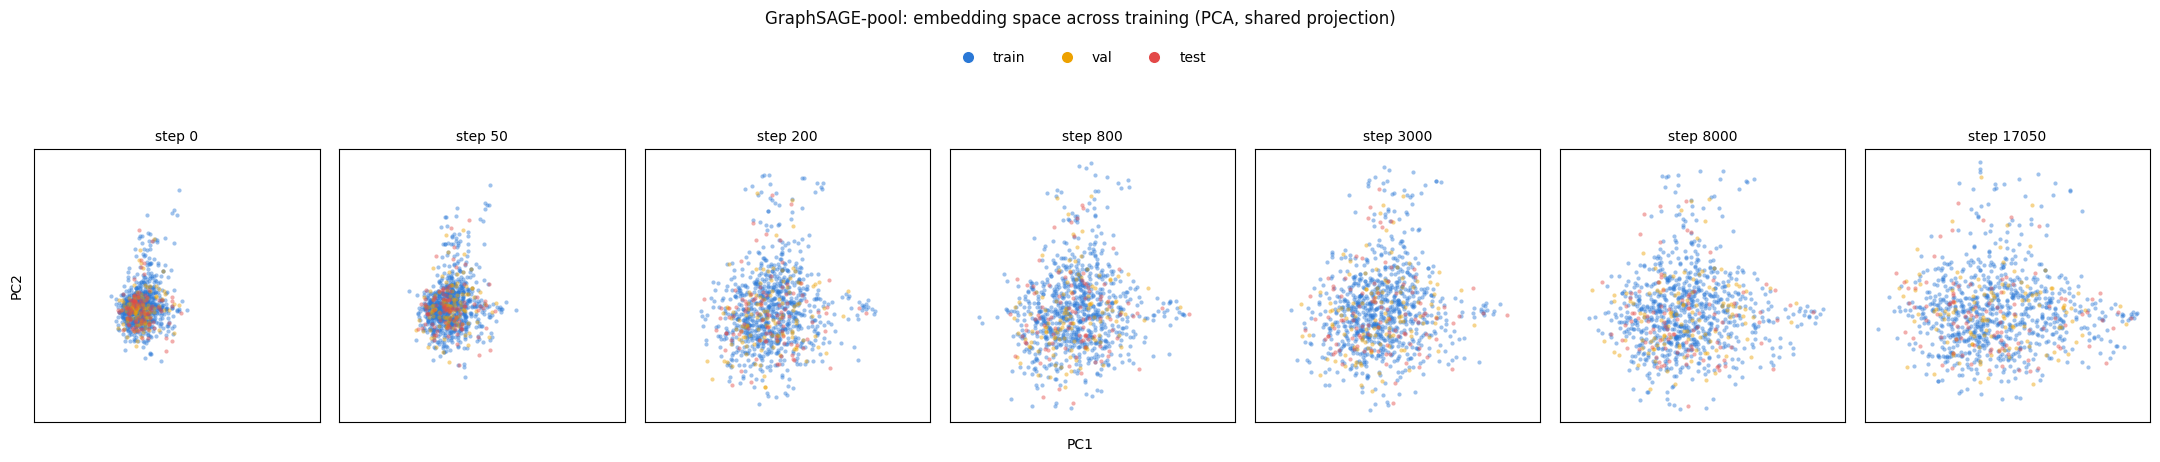

In [11]:
from sklearn.decomposition import PCA

pca_shared = PCA(n_components=2, random_state=123)
pca_shared.fit(snapshot_embeddings[SNAPSHOT_STEPS[-1]])
pca_coords = {step: pca_shared.transform(snapshot_embeddings[step]) for step in SNAPSHOT_STEPS}

fig_pca_stages = plot_stage_small_multiples(
    pca_coords, "GraphSAGE-pool: embedding space across training (PCA, shared projection)", "PC1", "PC2")
fig_pca_stages.savefig(os.path.join(RESULTS, "ppi_embedding_pca_stages.png"), dpi=140, bbox_inches="tight")
plt.show()


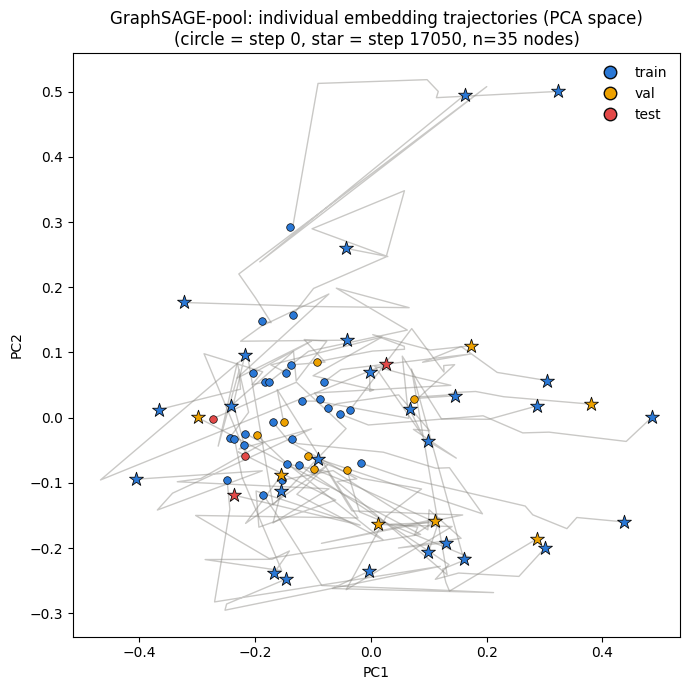

In [12]:
fig_pca_traj = plot_stage_trajectories(
    pca_coords, "GraphSAGE-pool: individual embedding trajectories (PCA space)", "PC1", "PC2")
fig_pca_traj.savefig(os.path.join(RESULTS, "ppi_embedding_pca_trajectories.png"), dpi=140)
plt.show()


**t-SNE view.** t-SNE has no simple out-of-sample "transform" for new
points, so to get one shared space across stages we fit it **jointly**: all
7 stages' embeddings for the same subsample are stacked into one matrix,
t-SNE is run once on the stack, and the result is split back out per stage.
This is more expensive than the PCA view above (subsampled to the same
~1,000 nodes to keep it tractable) but captures non-linear cluster structure
PCA can't.


C:\Users\feder\Desktop\GraphSAGE\.venv\lib\site-packages\sklearn\manifold\_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
C:\Users\feder\Desktop\GraphSAGE\.venv\lib\site-packages\sklearn\manifold\_t_sne.py:986: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  FutureWarning,


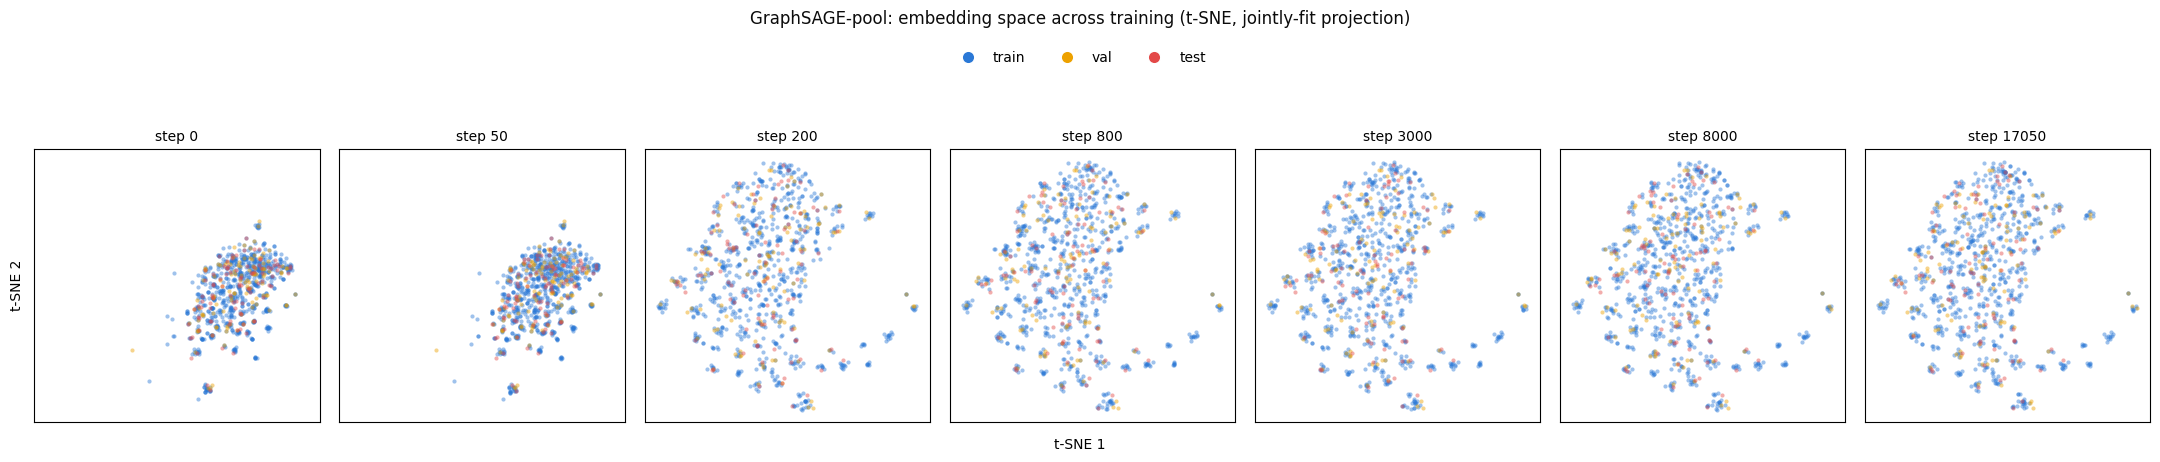

In [13]:
from sklearn.manifold import TSNE

stacked = np.vstack([snapshot_embeddings[step] for step in SNAPSHOT_STEPS])
tsne_joint = TSNE(n_components=2, perplexity=30, init="pca", random_state=123, n_iter=1000)
stacked_2d = tsne_joint.fit_transform(stacked)

n_each = len(sub_ids)
tsne_coords = {step: stacked_2d[i * n_each:(i + 1) * n_each] for i, step in enumerate(SNAPSHOT_STEPS)}

fig_tsne_stages = plot_stage_small_multiples(
    tsne_coords, "GraphSAGE-pool: embedding space across training (t-SNE, jointly-fit projection)", "t-SNE 1", "t-SNE 2")
fig_tsne_stages.savefig(os.path.join(RESULTS, "ppi_embedding_tsne_stages.png"), dpi=140, bbox_inches="tight")
plt.show()


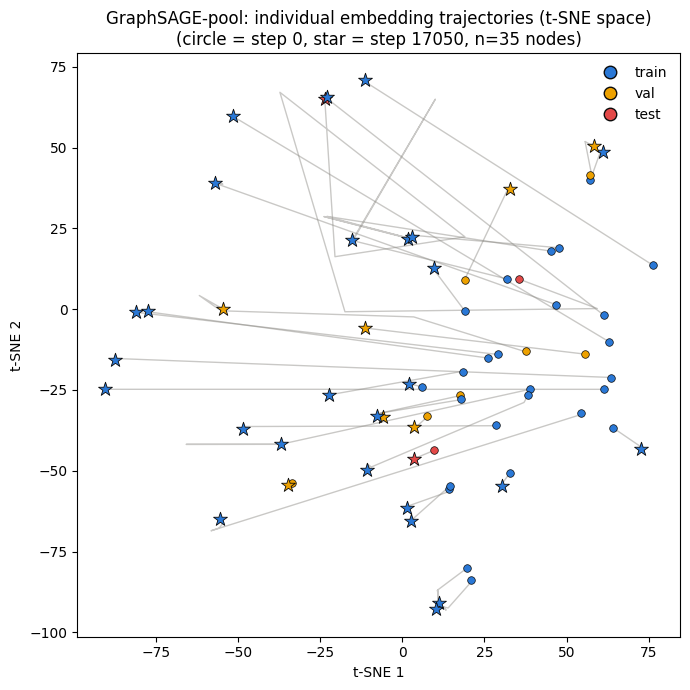

In [14]:
fig_tsne_traj = plot_stage_trajectories(
    tsne_coords, "GraphSAGE-pool: individual embedding trajectories (t-SNE space)", "t-SNE 1", "t-SNE 2")
fig_tsne_traj.savefig(os.path.join(RESULTS, "ppi_embedding_tsne_trajectories.png"), dpi=140)
plt.show()


**Reading the progression.** Both projections tell a consistent story:
at step 0 (random initialization) almost everything collapses into one dense
blob, since the untrained aggregator weights don't yet separate structurally
different nodes. Under t-SNE in particular, the cluster structure visible at
the final step is already largely in place by step 200 -- three orders of
magnitude fewer gradient steps than the full ~17,050-step epoch -- after
which training mostly refines relative distances and density rather than
discovering new cluster structure. That is consistent with Section 4.3 of
the paper, which reports diminishing returns from additional training and
sampling once the aggregators have enough signal to separate neighborhoods.


## 9. Theoretical analysis (overview)

The paper proves (Theorem 1, Appendix E) that, assuming every node has
distinct features, Algorithm 1 can approximate a node's **clustering
coefficient** (the fraction of closed triangles in its 1-hop neighborhood) to
arbitrary precision, using the *pooling* aggregator with $K=4$ iterations:

$$\forall \epsilon>0\ \ \exists\, \Theta^* \text{ s.t., after } K=4 \text{ iterations: } \quad |z_v - c_v| < \epsilon,\ \ \forall v\in V$$

where $c_v$ is the clustering coefficient of node $v$. The proof idea (Lemmas
1–3) is that, if node features are sufficiently distinct, a pooling
aggregator with ≥2 hidden layers can learn to map every node to a unique
**one-hot indicator vector** within its neighborhood — effectively "counting"
nodes and connections in the neighborhood, similar to how the
Weisfeiler-Lehman test iteratively refines node labels.

Empirically (Figure 3 of the paper), progressively replacing real features
with Gaussian noise, `GraphSAGE-pool` retains modest performance by exploiting
*only* graph structure, while `GraphSAGE-GCN` degrades faster — consistent
with the pooling aggregator's expressive capacity used in the proof of
Theorem 1.


## 10. Conclusions

- The reproduced baselines (Random, Raw features) and the 4 GraphSAGE
  variants (GCN, mean, LSTM, pool) on PPI, both supervised and unsupervised,
  reproduce the **qualitative ordering** reported in the paper:
  GraphSAGE-* ≫ Raw features > Random, with GCN consistently the weakest of
  the 4 variants and LSTM/pool the strongest, and supervised consistently
  ≥ unsupervised.
- Numerical differences from the paper are expected, due to:
  - a **single run** with default hyperparameters, instead of the full sweep
    (learning rate × model size) from Appendix C, which in the paper selects
    the best configuration per variant on a validation set;
  - TensorFlow version (1.15 here vs. the original ~1.x from 2017) and
    scikit-learn version for baselines/eval (`SGDClassifier` defaults have
    changed over time: `max_iter`/`tol` are no longer what they were in
    2017);
  - different seed/hardware (the paper used 4× Titan X Pascal GPUs; here a
    single RTX 2060).
- The Citation/WoS dataset cannot be reproduced "as-is" because it is
  licensed by Thomson Reuters (Appendix B of the paper); Reddit was excluded
  by explicit scope choice for this reproduction.
